calculate strike rate, boundary percentage, boundary per balls, and generate summary for a cricket player
 

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict

import os
load_dotenv()
api_key = os.environ.get("OPENAI_API_KEY")

In [2]:
model = ChatOpenAI()

In [ ]:
class CricketState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_percentage: float
    balls_per_boundary: float
    summary: str

In [27]:
def strike_rate(state: CricketState) -> float:
    strike_rate = state["runs"] / state["balls"] * 100
    # state["strike_rate"] = strike_rate
    return {"strike_rate": strike_rate}

In [28]:
def boundary_percentage(state: CricketState) -> float:
    total_boundaries = state["fours"] + state["sixes"]
    boundary_percentage = (total_boundaries / state["balls"]) * 100
    # state["boundary_percentage"] = boundary_percentage
    return {"boundary_percentage": boundary_percentage}

In [29]:
def balls_per_boundary(state: CricketState) -> float:
    total_boundaries = state["fours"] + state["sixes"]
    balls_per_boundary = state["balls"] / total_boundaries if total_boundaries > 0 else float('inf')
    # state["balls_per_boundary"] = balls_per_boundary
    return {"balls_per_boundary": balls_per_boundary}

In [30]:
def summary(state: CricketState) -> str:
    strike_rate = state['strike_rate']
    boundary_percentage = state['boundary_percentage']
    balls_per_boundary = state['balls_per_boundary']
    summary = f"""The player scored {state['runs']} runs in {state['balls']} balls,
               with a strike rate of {state['strike_rate']:.2f}. 
               They hit {state['fours']} fours and {state['sixes']} sixes, 
               resulting in a boundary percentage of {state['boundary_percentage']:.2f}%. 
               On average, they took {state['balls_per_boundary']:.2f} balls to hit a boundary."""
    state["summary"] = summary  
    return state 


In [31]:
#create a graph
graph = StateGraph(CricketState)

#add nodes
graph.add_node("strike_rate", strike_rate)
graph.add_node("boundary_percentage", boundary_percentage)
graph.add_node("balls_per_boundary", balls_per_boundary)
graph.add_node("summary", summary)

#add edges
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "boundary_percentage")
graph.add_edge(START, "balls_per_boundary")
graph.add_edge("strike_rate", "summary")
graph.add_edge("boundary_percentage", "summary")
graph.add_edge("balls_per_boundary", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()
intial_state = {"runs": 100, "balls": 60, "fours": 10, "sixes": 5}
final_state = workflow.invoke(intial_state)
print(final_state)

{'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5, 'strike_rate': 166.66666666666669, 'boundary_percentage': 25.0, 'balls_per_boundary': 4.0}


3 parallel nodes changing the state simultaneously creating conflict 
send only the node changed send partial state not full state

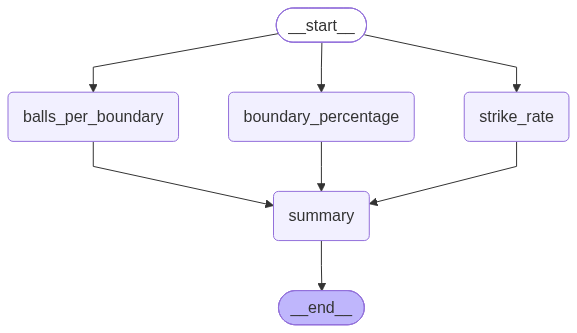

In [32]:
workflow